# Tag 10 — Fortgeschrittene
## XGBoost + CatBoost — House Prices

In [10]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "xgboost",
    "catboost",
    "lightgbm",
    "optuna"
])

0

In [11]:
import xgboost
print("xgboost OK ✅")
print(xgboost.__version__)

xgboost OK ✅
3.2.0


In [12]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = Path(r"C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_10_Boosting_Project")
if not PROJECT_DIR.exists():
    PROJECT_DIR = Path.cwd()
    while PROJECT_DIR.name not in ["Tag_10_Boosting_Project", ""] and PROJECT_DIR.parent != PROJECT_DIR:
        PROJECT_DIR = PROJECT_DIR.parent
DATA_DIR = PROJECT_DIR / "data" / "raw"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "02_fortgeschrittene"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_10_Boosting_Project
DATA_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_10_Boosting_Project\data\raw
OUTPUT_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_10_Boosting_Project\outputs\02_fortgeschrittene


In [13]:

TRAIN_PATH = DATA_DIR / "train.csv"
if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"train.csv not found in: {DATA_DIR}")

df = pd.read_csv(TRAIN_PATH)
df.columns = df.columns.str.strip()
print(df.shape)
display(df.head())


(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [14]:

target_col = "SalePrice"
if target_col not in df.columns:
    raise ValueError(f"SalePrice not found. Available columns: {df.columns.tolist()}")

X = df.drop(columns=[target_col])
y = df[target_col]
if "Id" in X.columns:
    X = X.drop(columns=["Id"])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)


(1168, 79) (292, 79)


In [15]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
], remainder="drop")

print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))


Numeric: 36
Categorical: 43


C:\Users\esmae\AppData\Local\Temp\ipykernel_39240\3919882222.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [16]:

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
try:
    from xgboost import XGBRegressor
except ModuleNotFoundError as e:
    raise ModuleNotFoundError("Please install xgboost: pip install xgboost") from e

xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=1))
])

param_grid = {
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__n_estimators": [100, 300]
}

grid = GridSearchCV(
    xgb_pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
    verbose=1
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

xgb_pred = grid.predict(X_test)
xgb_rmse = mean_squared_error(y_test, xgb_pred) ** 0.5
xgb_r2 = r2_score(y_test, xgb_pred)
print("XGBoost Test RMSE:", xgb_rmse)
print("XGBoost Test R2:", xgb_r2)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300}
Best CV RMSE: 26045.255859375
XGBoost Test RMSE: 25337.084915198906
XGBoost Test R2: 0.9163050055503845


In [17]:

try:
    from catboost import CatBoostRegressor
    catboost_available = True
except ModuleNotFoundError:
    catboost_available = False
    print("CatBoost is not installed. Install with: pip install catboost")

cat_result = None
if catboost_available:
    X_train_cat = X_train.copy()
    X_test_cat = X_test.copy()
    cat_features = X_train_cat.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    for col in cat_features:
        X_train_cat[col] = X_train_cat[col].astype(str).fillna("missing")
        X_test_cat[col] = X_test_cat[col].astype(str).fillna("missing")
    for col in X_train_cat.select_dtypes(include=["int64", "float64"]).columns:
        med = X_train_cat[col].median()
        X_train_cat[col] = X_train_cat[col].fillna(med)
        X_test_cat[col] = X_test_cat[col].fillna(med)

    cat_model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )
    cat_model.fit(
        X_train_cat,
        y_train,
        cat_features=cat_features,
        eval_set=(X_test_cat, y_test),
        early_stopping_rounds=20,
        verbose=False
    )
    cat_pred = cat_model.predict(X_test_cat)
    cat_rmse = mean_squared_error(y_test, cat_pred) ** 0.5
    cat_r2 = r2_score(y_test, cat_pred)
    cat_result = {"model":"CatBoost", "test_rmse":cat_rmse, "test_r2":cat_r2, "best_iteration":cat_model.best_iteration_}
    print(cat_result)


C:\Users\esmae\AppData\Local\Temp\ipykernel_39240\3783590463.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train_cat.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


{'model': 'CatBoost', 'test_rmse': 26664.891644428597, 'test_r2': 0.9073029715811965, 'best_iteration': 442}


,model,test_rmse,test_r2,best_iteration
0,Best XGBoost,25337.084915,0.916305,NaN
1,CatBoost,26664.891644,0.907303,442.0


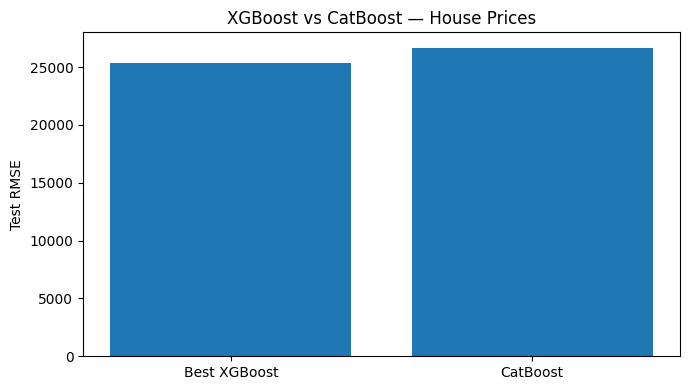

In [18]:

comparison = [
    {"model":"Best XGBoost", "test_rmse":xgb_rmse, "test_r2":xgb_r2, "best_iteration":np.nan}
]
if cat_result is not None:
    comparison.append(cat_result)
comparison_df = pd.DataFrame(comparison).sort_values("test_rmse")
display(comparison_df)
comparison_df.to_csv(OUTPUT_DIR / "fortgeschrittene_xgboost_catboost_comparison.csv", index=False)

plt.figure(figsize=(7, 4))
plt.bar(comparison_df["model"], comparison_df["test_rmse"])
plt.ylabel("Test RMSE")
plt.title("XGBoost vs CatBoost — House Prices")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fortgeschrittene_xgboost_catboost_rmse.png", dpi=200)
plt.show()
